## kNN Malli ( K-Nearest Neighbors )

k-Nearest Neighbors (kNN) -malli (k-lähintä naapuria) luokittelee uuden tiedon tarkastelemalla sille lähimpiä $k$ kappaletta opetusdatan pistettä ja valitsemalla niiden enemmistön mukaisen luokan. Malli ei opi erillistä kaavaa etukäteen (lazy learning), vaan se tekee päätökset vertaamalla uutta kohdetta suoraan olemassa olevaan dataan ennustushetkellä.

#### Hyödyt
 - Helppo ymmärtää ja havainnoida.
 - Helppo lisätä uutta dataa.

#### Haitat
 - Hidas isoilla datamäärällä.
 - Huono skaalautuvuus.
 - Raskas prosessointi

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

iris = pd.read_csv('../../datasets/iris.csv').drop(columns = ['sepal_length','sepal_width'])
iris

,petal_length,petal_width,species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa
...,...,...,...
145,5.2,2.3,virginica
146,5.0,1.9,virginica
147,5.2,2.0,virginica
148,5.4,2.3,virginica


In [188]:
# euclidean distance
#a = 3000
#b = np.sqrt(np.pow( (10-5), 2) + (5-4) )
#b 

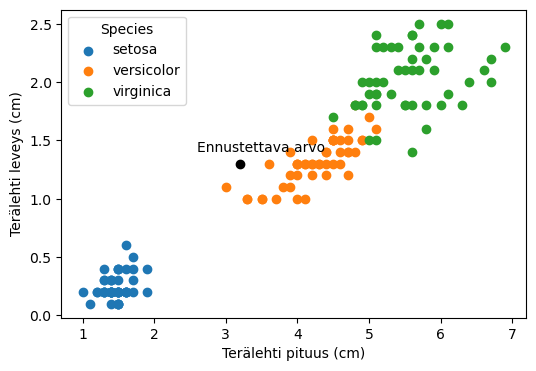

In [247]:
# Generate a scatter plot of the dataset (coloring by species)
fig, ax = plt.subplots(figsize=(6, 4))

for target_name, group in iris.groupby('species'):
    ax.scatter(group.petal_length, group.petal_width, label=target_name)
    
ax.plot([3.2], [1.3], 'o', c='black') # new flower sample data point 
ax.text(2.6, 1.4, 'Ennustettava arvo') # annotation text
ax.legend(title='Species')
ax.set(xlabel = 'Terälehti pituus (cm)', ylabel = 'Terälehti leveys (cm)' )

plt.show()

---
## kNN malli perusteet

In [192]:
from sklearn.neighbors import KNeighborsClassifier

#kNN model?????? valmis paketti, ei tarvii koodata matikkaa itse

model = KNeighborsClassifier(n_neighbors = 3) #k valmis algoritmi, jossa (n_neighbours == k).

X = iris.drop(columns = 'species') # inputs
y = iris['species'] # targets
model.fit(X, y) # build the classifier #KOULUTA MALLI

KNeighborsClassifier(n_neighbors=3)

In [194]:
#Ennusta ylemmän mallin perusteella mikä syötetty kukka on
model.predict(pd.DataFrame({'petal_length': [3.2], 'petal_width':[1.3]}))

array(['versicolor'], dtype=object)

In [196]:
#model.predict(X) == y
#sum(model.predict(X) == y)


---
## Normalisointi

| Ikä / Age | Palkka / Salary (€) |
| :--- | :--- |
| 19.0 | 2100 |
| 34.0 | 3200 |
| 35.8 | 3400 |
| 36.8 | 3550 |
| 37.8 | 3700 |
| 38.8 | 3900 |
| 41.4 | 4200 |

- Jos otannan luvut ovat todella suuria ja pieniä (skaalautuvuus), isompi dominoi -> palkka dominoi ja ikää ei oteta huomioon.
    - Ongelma korjataan normalisoimalla!
        1. Lasketaan dataseteille keskiarvo<b>(34.8)</b> ja keskihajonta <b>(6.8)</b>. Eli jokainen sarake lasketaan erikseen ja normalisoidaan omanaan.
        2.  Muokataan jokainen arvo normalisoidulla arvolla -->  <b>[ IKÄ: 19 - > (19-34.8)/6.8 = -2.3 ]</b>

<br><br>
<b>.fit():</b> Opettaa mallille tai muuntajalle datan säännöt laskemalla tarvittavat arvot (kuten keskiarvon ja keskihajonnan) annetun opetusdatan perusteella.

<b>.transform():</b> Soveltaa opittuja sääntöjä (kuten edellä laskettuja arvoja) dataan ja muuntaa sen haluttuun muotoon (esim. skaalaa luvut).

<b>.fit_transform():</b> Tehdään molemmat vaiheet kerralla: se opettelee säännöt datasta (.fit) ja muuntaa sen heti perään (.transform).

In [282]:
#EI TARVII LASKEE ITE... SKLEARN KIRJASTO HOITAA KAIKEN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #luodaan olio!

#columns=X.columns -> poimi alkuperäisestä dataframesta sarakkeet ja luo niiden perusteella!
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) # preserves column names

In [284]:
scaler.var_ #keskihajonta (variance)

array([3.09242489, 0.57853156])

In [286]:
scaler.mean_ #keskiarvo

array([3.75866667, 1.19866667])

In [265]:
#SYÖTETTY DATA TÄYTYY OLLA KANSSA OIKEIN NORMALISOITU!!!
#Uusi syöte malliin jossa se skaalataan oikien.

X_new = pd.DataFrame({'petal_length': [3.2], 'petal_width':[1.3]}) #uusi arvo
X_new_scaled = pd.DataFrame(scaler.transform(X_new), columns=X_scaled.columns) #uusi arvo skaalattuna

model.predict(X_new_scaled)

array(['setosa'], dtype=object)

Uudelle datalle (kuten testidatalle) täytyy aina käyttää tismalleen samoja sääntöjä (keskiarvo ja keskihajonta), jotka opittiin alkuperäisestä opetusdatasta (training data). Jos käyttäisit fit_transform(), järjestelmä laskisi uudet säännöt vain uuden datan perusteella, jolloin mittakaava muuttuu vääräksi. Englanninkielinen riski tälle on data leakage.

In [293]:
iris_np = pd.read_csv('../../datasets/iris.csv').values #tallenna luvut numpy arrayksi

#Poimii neljä ensimmäistä saraketta syötemuuttujiksi eli piirteiksi (features, X) ja muuttaa tietotyypiksi liukuluvut (float).
X = iris_np[:, :4].astype(float)

#Poimii viidennen sarakkeen tavoitemuuttujaksi eli luokiksi (target labels / classes, y).
y = iris_np[:, 4]

#axis=0: Laskee ylhäältä alas, eli käsittelee sarakkeita (columns / features).
#axis=1: Laskee vasemmalta oikealle, eli käsittelee rivejä (rows / samples).

#Standardoi (standardization / Z-score normalization) piirteet sarakekohtaisesti vähentämällä keskiarvon (mean) 
#ja jakamalla keskihajonnalla (standard deviation).
X_scaled = (X - np.mean(X, axis=0))/np.std(X, axis=0)

#Alustaa k-lähintä naapuria -luokittimen (k-Nearest Neighbors classifier) käyttäen kolmea naapuria (n_neighbors = 3).
model = KNeighborsClassifier(n_neighbors = 3)

#Opettaa (fit / train) mallin annetulla skaalatulla opetusdatalla (X_scaled) ja sen luokilla (y)
model.fit(X_scaled, y)

KNeighborsClassifier(n_neighbors=3)

In [303]:
X_new = np.array([[5.0, 2.5, 3.2, 1.3]]) # sample input values (original)
X_new_scaled = (X_new - np.mean(X, axis=0))/np.std(X, axis=0) # standardized

model.predict(X_new_scaled)

array(['versicolor'], dtype=object)

---
# kNN tulosten analyysi kokeeseen (Tarkkuus, saanto & täsmällisyys)!!

### Mittarit ( Metriikat )

<b>Tarkkuus (Accuracy):</b> Kaikkien tehtyjen arvioiden yhteisosuus, jotka menivät oikeaan (sekä oikeat osumat että oikeat hylkäykset).

<b>Saanto (Recall):</b> Kuinka suuri osa kaikista todellisuudessa olemassa olevista positiivisista tapauksista saatiin onnistuneesti kaivettua esiin.

<b>Täsmällisyys (Precision):</b> Kuinka suuri osa niistä tapauksista, jotka järjestelmä väitti positiivisiksi, olivat todellisuudessa sitä (eivätkä vääriä hälytyksiä).


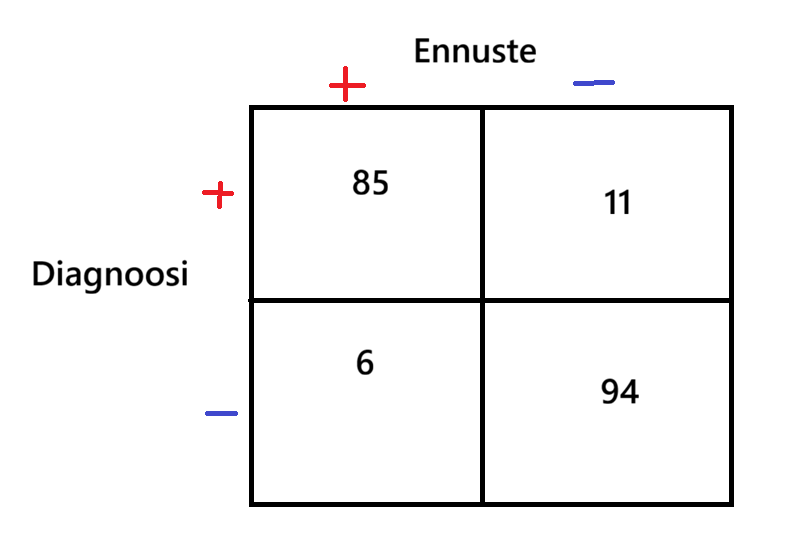

- <b>Tarkkuus (Accuracy):</b> (85 + 94) / (85+ 11 + 6 + 94) | (Oikeat ennusteet jaettuna kaikilla)
- <b>Saanto (Recall):</b> (85 / (85 + 11) ) | (Oikeat ennusteet jaettuna kaikilla joilla oli oikeasti diagnoosi)
- <b>Täsmällisyys (Precision):</b> (85 / ( 85 + 6 )) | (Oikeat ennusteet jaettuna kaikilla jotka oli diagnosoitu)

### Confusion Matrix:
- <b>False positive:</b> Vastaus on on oletettu "True", ja se todellisuudessa on "False".
- <b>False negative:</b> Vastaus on oletettu "False", mutta todellisuudessa se on "True".
- <b>True negative:</b> Vastaus on oletettu "False", ja se todellisuudessa se on "False".
- <b>True positive:</b> Vastaus on oletettu "True", ja se todellisuudessa on "True".

HUOM. Mallinsuorituskyvyn mittaaminen pitäisi tehdä datalla joka ei ole koulutus dataa. Eritetään opetusjoukko ja testijoukko.

In [295]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#PELKISTETTY CONFUSION MATRIX!

y_pred = model.predict(X_scaled)
confusion_matrix(y, y_pred) #print

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0,  4, 46]], dtype=int64)

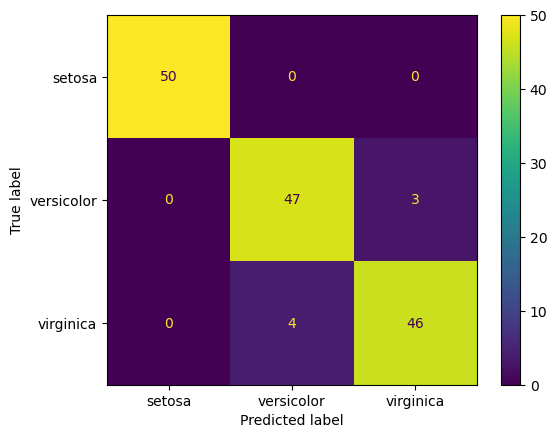

In [297]:
#VISUAALINEN "CONFUSION MATRIX"

y_pred = model.predict(X_scaled)
cm = confusion_matrix(y, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=['setosa','versicolor','virginica'])
cmd.plot() #print


- <b>Tarkkuus (Accuracy):</b> 143/150 = 95% tarkkuus [ OIKEAT ENNUSTEET / KAIKKI ENNUSTETTAVAT ]
- <b>Saanto (Recall) = 47/50):</b> 94% (Versicolor) [OIKEIN ENNUSTETUT / VERSICOLOREIDEN MÄÄRÄ]
- <b>Täsmällisyys (Precision):</b> 47/51 = 92% (Versicolor) [OIKEIN ENNUSTETUT / KAIKKI ARVATUT VERSICOLORIT]

(KOKEESEEN)

In [158]:
print(classification_report(y, y_pred)) #tarkkuus; precision, recall & accuracy

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.94      0.93        50
   virginica       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

